<a href="https://colab.research.google.com/github/rajneeshpandeyseo-a11y/property-price-prediction/blob/main/property_price_prediction_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

df = pd.read_csv("/content/drive/MyDrive/Data Science Carrior 247/mini project/property_price_data (1).csv")
df.head(20)

,Prop_Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,PropStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,YrSold,SaleCondition,SalePrice
0,PRO504,20,RL,100.0,15537,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,1Story,7,8,1959,1997,Gable,CompShg,BrkFace,Wd Sdng,TA,TA,CBlock,TA,TA,No,1501,GasA,TA,Y,SBrkr,1801,1,0,2,0,1,1,TA,6,Typ,2,TA,Attchd,1959.0,Fin,2,484,TA,TA,Y,0,54,0,0,161,0,NaN,GdWo,NaN,0,2010,Normal,288330
1,PRO102,60,RL,77.0,9534,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,2Story,6,5,1985,1985,Gable,CompShg,HdBoard,HdBoard,Gd,TA,CBlock,Gd,TA,No,741,GasA,TA,Y,SBrkr,1732,0,0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,1985.0,Fin,2,476,TA,TA,Y,192,46,0,0,0,0,NaN,NaN,NaN,0,2010,Normal,183164
2,PRO609,70,RL,NaN,12781,Pave,NaN,Reg,HLS,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,2Story,8,6,1934,1998,Gable,CompShg,BrkFace,Wd Sdng,TA,TA,PConc,Gd,TA,Mn,987,GasA,TA,Y,SBrkr,3194,0,0,2,1,4,1,TA,10,Typ,2,Gd,Basment,1934.0,Unf,2,380,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,2007,Alloca,362145
3,PRO1090,120,FV,37.0,3728,Pave,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,TwnhsE,1Story,8,5,2005,2005,Gable,CompShg,MetalSd,MetalSd,Gd,TA,PConc,Gd,TA,No,1247,GasA,Ex,Y,SBrkr,1247,1,0,1,1,1,1,Gd,4,Typ,1,Gd,Attchd,2005.0,Fin,2,550,TA,TA,Y,0,84,0,0,0,0,NaN,NaN,NaN,0,2006,Normal,196079
4,PRO820,120,RL,44.0,6606,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,TwnhsE,1Story,7,5,2009,2010,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,Mn,1358,GasA,Ex,Y,SBrkr,1358,1,0,2,0,2,1,Gd,6,Typ,1,Gd,Attchd,2010.0,RFn,2,484,TA,TA,Y,192,35,0,0,0,0,NaN,NaN,NaN,0,2010,Partial,228515
5,PRO685,60,RL,58.0,18002,Pave,NaN,IR2,Lvl,AllPub,CulDSac,Gtl,NoRidge,Norm,Norm,1Fam,2Story,7,5,1998,1998,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,No,1195,GasA,Gd,Y,SBrkr,1839,0,0,2,1,4,1,TA,7,Typ,0,NaN,Attchd,1998.0,Fin,2,486,TA,TA,Y,0,81,0,0,0,0,NaN,NaN,NaN,0,2010,Normal,224119
6,PRO1281,20,RL,67.0,9769,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,7,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,No,1573,GasA,Ex,Y,SBrkr,1573,1,0,2,0,3,1,Gd,6,Typ,0,NaN,Attchd,2002.0,RFn,2,544,TA,TA,Y,0,72,0,0,0,0,NaN,NaN,NaN,0,2009,Normal,228107
7,PRO921,60,RL,70.0,8653,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,2Story,6,5,1994,1994,Gable,CompShg,HdBoard,HdBoard,Gd,Gd,PConc,Gd,Gd,No,928,GasA,Ex,Y,SBrkr,1547,0,1,2,1,3,1,Gd,7,Typ,0,NaN,Attchd,1994.0,RFn,2,471,TA,TA,Y,300,87,0,0,0,0,NaN,NaN,NaN,0,2007,Normal,203953
8,PRO1454,20,RL,90.0,17720,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,Gd,TA,No,1140,GasA,Ex,Y,SBrkr,1140,0,0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,36,56,0,0,0,0,NaN,NaN,NaN,0,2006,Abnorml,87468
9,PRO541,20,RL,85.0,15369,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,9,5,2006,2006,Hip,CompShg,VinylSd,VinylSd,Ex,TA,PConc,Ex,TA,Av,1838,GasA,Ex,Y,SBrkr,1838,1,0,2,0,2,1,Ex,8,Typ,1,Gd,Attchd,2006.0,Fin,3,765,TA,TA,Y,270,68,0,0,0,0,NaN,NaN,NaN,0,2009,Normal,313697


In [ ]:
# Data Expolration
print("\n ======= Dataset Info =======")
df.info()

print("\n ======= Size of Data =======")
print("\n number of rows :", df.shape[0])
print("\n number of columns :", df.shape[1])

print("\n ======= Data Summarr Statics =======")
df.describe()


 ======= Dataset Info =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Prop_Id        970 non-null    object 
 1   MSSubClass     970 non-null    int64  
 2   MSZoning       970 non-null    object 
 3   LotFrontage    789 non-null    float64
 4   LotArea        970 non-null    int64  
 5   Street         970 non-null    object 
 6   Alley          56 non-null     object 
 7   LotShape       970 non-null    object 
 8   LandContour    970 non-null    object 
 9   Utilities      970 non-null    object 
 10  LotConfig      970 non-null    object 
 11  LandSlope      970 non-null    object 
 12  Neighborhood   970 non-null    object 
 13  Condition1     970 non-null    object 
 14  Condition2     970 non-null    object 
 15  BldgType       970 non-null    object 
 16  PropStyle      970 non-null    object 
 17  OverallQual    970 non-

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
count,970.000000,789.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,918.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000,970.000000
mean,58.092784,69.447402,11208.956701,6.143299,5.547423,1971.496907,1984.741237,1079.728866,1532.874227,0.437113,0.060825,1.577320,0.387629,2.872165,1.044330,6.559794,0.640206,1978.879085,1.775258,474.715464,93.124742,48.015464,21.357732,4.261856,16.271134,4.152577,48.257732,2007.815464,184272.595876
std,42.962071,24.139429,10153.538896,1.396990,1.091443,30.247798,20.659310,463.970814,546.642210,0.518655,0.247613,0.549604,0.504113,0.807695,0.220455,1.640884,0.646840,24.733202,0.737473,214.203638,122.884207,66.676218,59.281725,33.019578,58.939315,49.241171,595.105731,1.336156,82061.647461
min,20.000000,21.000000,1663.000000,1.000000,1.000000,1875.000000,1950.000000,0.000000,438.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000,35336.000000
25%,20.000000,57.000000,8147.500000,5.000000,5.000000,1954.000000,1966.250000,808.000000,1141.750000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1962.000000,1.000000,336.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,132225.000000
50%,50.000000,68.000000,10174.500000,6.000000,5.000000,1974.000000,1994.000000,1008.000000,1469.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1981.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,165641.500000
75%,70.000000,80.000000,12482.250000,7.000000,6.000000,2000.000000,2004.000000,1324.000000,1792.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000,215268.250000
max,190.000000,313.000000,216301.000000,10.000000,9.000000,2009.000000,2010.000000,6110.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,6.000000,3.000000,12.000000,3.000000,2010.000000,4.000000,1418.000000,736.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,2010.000000,758639.000000


In [ ]:
# Check missing values
missing_values = df.isnull().sum()[df.isnull().sum()>0]
print(missing_values)

LotFrontage     181
Alley           914
BsmtQual         23
BsmtCond         23
BsmtExposure     24
FireplaceQu     437
GarageType       52
GarageYrBlt      52
GarageFinish     52
GarageQual       52
GarageCond       52
PoolQC          963
Fence           801
MiscFeature     941
dtype: int64


In [ ]:
# Drop columns with too many missing values

df = df.drop(columns = ["Prop_Id","PoolQC", "Alley", "Fence","MiscFeature"])

# Separate Numerical & Categorical Columns
numberic_cols = df.select_dtypes(include = ["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include = ["object"]).columns

# Fill Missing values
# Numberical columns -> fill with Median

for col in numberic_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill Categorical columns

for col in categorical_cols:
    df[col].fillna("Missing", inplace=True)

/tmp/ipython-input-3457919763.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3457919763.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
df.head(20)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,PropStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SaleCondition,SalePrice
0,20,RL,100.0,15537,Pave,IR1,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,1Story,7,8,1959,1997,Gable,CompShg,BrkFace,Wd Sdng,TA,TA,CBlock,TA,TA,No,1501,GasA,TA,Y,SBrkr,1801,1,0,2,0,1,1,TA,6,Typ,2,TA,Attchd,1959.0,Fin,2,484,TA,TA,Y,0,54,0,0,161,0,0,2010,Normal,288330
1,60,RL,77.0,9534,Pave,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,2Story,6,5,1985,1985,Gable,CompShg,HdBoard,HdBoard,Gd,TA,CBlock,Gd,TA,No,741,GasA,TA,Y,SBrkr,1732,0,0,2,1,3,1,Gd,7,Typ,1,TA,Attchd,1985.0,Fin,2,476,TA,TA,Y,192,46,0,0,0,0,0,2010,Normal,183164
2,70,RL,68.0,12781,Pave,Reg,HLS,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,2Story,8,6,1934,1998,Gable,CompShg,BrkFace,Wd Sdng,TA,TA,PConc,Gd,TA,Mn,987,GasA,TA,Y,SBrkr,3194,0,0,2,1,4,1,TA,10,Typ,2,Gd,Basment,1934.0,Unf,2,380,TA,TA,Y,0,0,0,0,0,0,0,2007,Alloca,362145
3,120,FV,37.0,3728,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,TwnhsE,1Story,8,5,2005,2005,Gable,CompShg,MetalSd,MetalSd,Gd,TA,PConc,Gd,TA,No,1247,GasA,Ex,Y,SBrkr,1247,1,0,1,1,1,1,Gd,4,Typ,1,Gd,Attchd,2005.0,Fin,2,550,TA,TA,Y,0,84,0,0,0,0,0,2006,Normal,196079
4,120,RL,44.0,6606,Pave,IR1,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,TwnhsE,1Story,7,5,2009,2010,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,Mn,1358,GasA,Ex,Y,SBrkr,1358,1,0,2,0,2,1,Gd,6,Typ,1,Gd,Attchd,2010.0,RFn,2,484,TA,TA,Y,192,35,0,0,0,0,0,2010,Partial,228515
5,60,RL,58.0,18002,Pave,IR2,Lvl,AllPub,CulDSac,Gtl,NoRidge,Norm,Norm,1Fam,2Story,7,5,1998,1998,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,No,1195,GasA,Gd,Y,SBrkr,1839,0,0,2,1,4,1,TA,7,Typ,0,Missing,Attchd,1998.0,Fin,2,486,TA,TA,Y,0,81,0,0,0,0,0,2010,Normal,224119
6,20,RL,67.0,9769,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,7,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,No,1573,GasA,Ex,Y,SBrkr,1573,1,0,2,0,3,1,Gd,6,Typ,0,Missing,Attchd,2002.0,RFn,2,544,TA,TA,Y,0,72,0,0,0,0,0,2009,Normal,228107
7,60,RL,70.0,8653,Pave,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,2Story,6,5,1994,1994,Gable,CompShg,HdBoard,HdBoard,Gd,Gd,PConc,Gd,Gd,No,928,GasA,Ex,Y,SBrkr,1547,0,1,2,1,3,1,Gd,7,Typ,0,Missing,Attchd,1994.0,RFn,2,471,TA,TA,Y,300,87,0,0,0,0,0,2007,Normal,203953
8,20,RL,90.0,17720,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,Gd,TA,No,1140,GasA,Ex,Y,SBrkr,1140,0,0,1,0,3,1,TA,6,Typ,0,Missing,Missing,1981.0,Missing,0,0,Missing,Missing,Y,36,56,0,0,0,0,0,2006,Abnorml,87468
9,20,RL,85.0,15369,Pave,Reg,Lvl,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,9,5,2006,2006,Hip,CompShg,VinylSd,VinylSd,Ex,TA,PConc,Ex,TA,Av,1838,GasA,Ex,Y,SBrkr,1838,1,0,2,0,2,1,Ex,8,Typ,1,Gd,Attchd,2006.0,Fin,3,765,TA,TA,Y,270,68,0,0,0,0,0,2009,Normal,313697


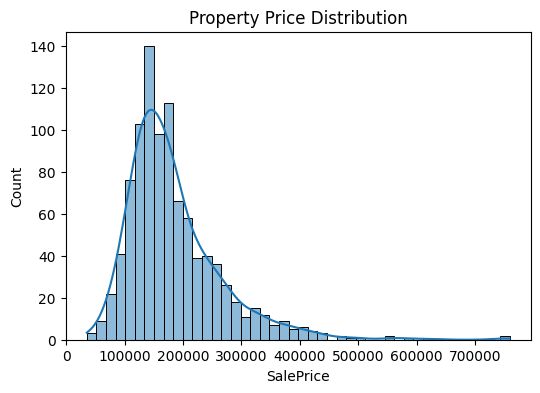

In [ ]:
# Price Distribution (Histogram + Bell Curve)

plt.figure(figsize=(6,4))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Property Price Distribution")
plt.show()

In [ ]:
# To make the price
# To make this biased data to unbiased data (Right Skwed - Normal Distribution)
# we use Log Transformation of Sale price

df["SalePrice_log"] = np.log1p(df["SalePrice"])

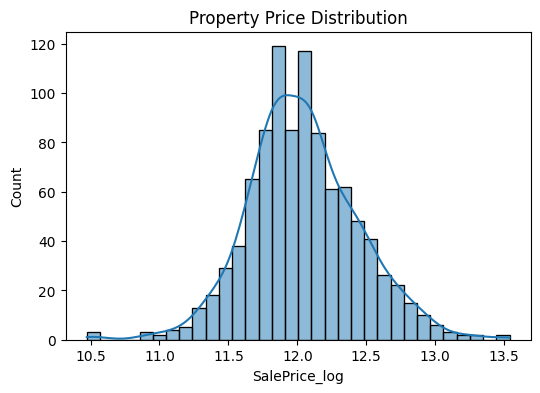

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Property Price Distribution")
plt.show()

In [ ]:
# Convert Catgeorical Data -> Numerical. ML model doesnt pricess categorical data

df_encoded = pd.get_dummies(df)
df_encoded.head(20)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice,SalePrice_log,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,...,Functional_Sev,Functional_Typ,FireplaceQu_Ex,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Missing,FireplaceQu_Po,FireplaceQu_TA,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_Missing,GarageFinish_Fin,GarageFinish_Missing,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Ex,GarageQual_Fa,GarageQual_Gd,GarageQual_Missing,GarageQual_Po,GarageQual_TA,GarageCond_Ex,GarageCond_Fa,GarageCond_Gd,GarageCond_Missing,GarageCond_Po,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,100.0,15537,7,8,1959,1997,1501,1801,1,0,2,0,1,1,6,2,1959.0,2,484,0,54,0,0,161,0,0,2010,288330,12.571864,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False
1,60,77.0,9534,6,5,1985,1985,741,1732,0,0,2,1,3,1,7,1,1985.0,2,476,192,46,0,0,0,0,0,2010,183164,12.118143,False,False,False,True,False,False,True,False,False,False,...,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False
2,70,68.0,12781,8,6,1934,1998,987,3194,0,0,2,1,4,1,10,2,1934.0,2,380,0,0,0,0,0,0,0,2007,362145,12.799803,False,False,False,True,False,False,True,False,False,False,...,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False
3,120,37.0,3728,8,5,2005,2005,1247,1247,1,0,1,1,1,1,4,1,2005.0,2,550,0,84,0,0,0,0,0,2006,196079,12.186278,False,True,False,False,False,False,True,True,False,False,...,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False
4,120,44.0,6606,7,5,2009,2010,1358,1358,1,0,2,0,2,1,6,1,2010.0,2,484,192,35,0,0,0,0,0,2010,228515,12.339362,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True
5,60,58.0,18002,7,5,1998,1998,1195,1839,0,0,2,1,4,1,7,0,1998.0,2,486,0,81,0,0,0,0,0,2010,224119,12.319937,False,False,False,True,False,False,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False
6,20,67.0,9769,7,5,2002,2002,1573,1573,1,0,2,0,3,1,6,0,2002.0,2,544,0,72,0,0,0,0,0,2009,228107,12.337574,False,False,False,True,False,False,True,True,False,False,...,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False
7,60,70.0,8653,6,5,1994,1994,928,1547,0,1,2,1,3,1,7,0,1994.0,

In [ ]:
# Define Features

X = df_encoded.drop(["SalePrice","SalePrice_log"],axis=1)
y = df_encoded["SalePrice_log"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Model Training - Random Forest

rf_model = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predictions
y_pred_log = rf_model.predict(X_test_scaled)
# Convert predictions back to original values
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

In [ ]:
#  Model Evaluation
mae = mean_absolute_error(y_test_actual,y_pred_actual)
rmse = mean_squared_error(y_test_actual,y_pred_actual)

r2 = r2_score(y_test_actual,y_pred_actual)

print("Random Forest Regressor Model")
print("\n Evaluation Metrics:")

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Random Forest Regressor Model

 Evaluation Metrics:
MAE: 18366.64374436327
RMSE: 961650690.2024782
R2: 0.8641660378649497


In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({"Features":X.columns,"Importance":rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(10)

,Features,Importance
3,OverallQual,0.541576
8,GrLivArea,0.102089
18,GarageCars,0.072567
7,TotalBsmtSF,0.056028
5,YearBuilt,0.022843
19,GarageArea,0.021417
2,LotArea,0.016492
4,OverallCond,0.010274
6,YearRemodAdd,0.007311
1,LotFrontage,0.006578


In [ ]:
print("Key Insights:")
print("1. Quality & Living Area strongly influence house prices")
print("2. Garage area and Basement size are very important value drivers.")
print("3. Construction Year also somehow affects on the overall pricing.")

Key Insights:
1. Quality & Living Area strongly influence house prices
2. Garage area and Basement size are very important value drivers.
3. Construction Year also somehow affects on the overall pricing.
